### 01_eda_preprocessing.ipynb 노트북에 다음을 포함 합니다:
> - 데이터셋을 불러와 head(), info(), describe() 결과를 출력.
> - value_counts(normalize=True)로 타깃 클래스 분포를 보고하고, 그것이 평가 지표 선택에 미치는 영향을 서술.
> - 결측값(열별·전체)과 이상치(boxplot + IQR 또는 z-score)를 최소한 연속형 특성(age, trestbps, chol, thalach, oldpeak 등)에 대해 탐지.
> - 결측값(컬럼별로 삭제 vs. 평균/중앙값/KNN 대치를 정당화), 이상치, 빈 컬럼, 중복을 처리하는 전처리 파이프라인 구성. 일회성 셀이 아니라 새 데이터에 그대로 재적용 가능한 함수 또는 sklearn.pipeline.Pipeline 형태여야 합니다.
> - 마크다운으로 짧게: "EDA 가 무엇을 알려 주었으며, 그에 따라 전처리에서 무엇을 어떻게 바꾸었는가?"

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

##### 데이터셋을 불러와 head(), info(), describe() 결과를 출력.

In [20]:
df = pd.read_csv('../data/processed.cleveland.data', header=None, na_values='?')
df.columns=['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
df['target'] = (df['target'] > 0).astype(int)

In [28]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [29]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,0.499120
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


##### value_counts(normalize=True)로 타깃 클래스 분포를 보고하고, 그것이 평가 지표 선택에 미치는 영향을 서술.

target
0    0.541254
1    0.458746
Name: proportion, dtype: float64


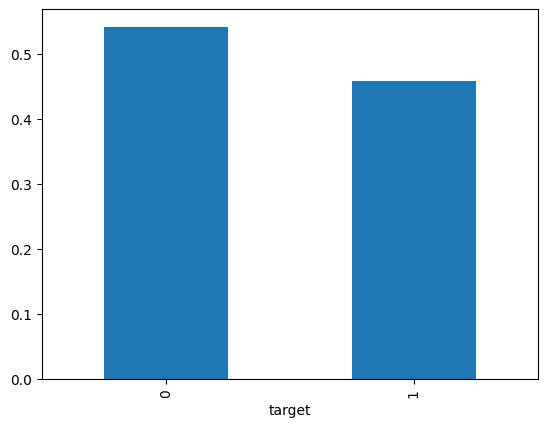

In [44]:
print(df['target'].value_counts(normalize=True))
df['target'].value_counts(normalize=True).plot(kind='bar')
plt.show()

> - 정상 환자: 0.54%
> - 심장병 환자: 0.46%
- 정상환자와 심장병 환자의 비율이 적절히 분포해있다.
- 심장병환자는 FN이 나와 실제 환자를 못찾아낼 경우 위험함으로 재현율(Recall)이 중요하게 고려 해야한다.

##### 결측값(열별·전체)과 이상치(boxplot + IQR 또는 z-score)를 최소한 연속형 특성(age, trestbps, chol, thalach, oldpeak 등)에 대해 탐지.

ca      4
thal    2
dtype: int64


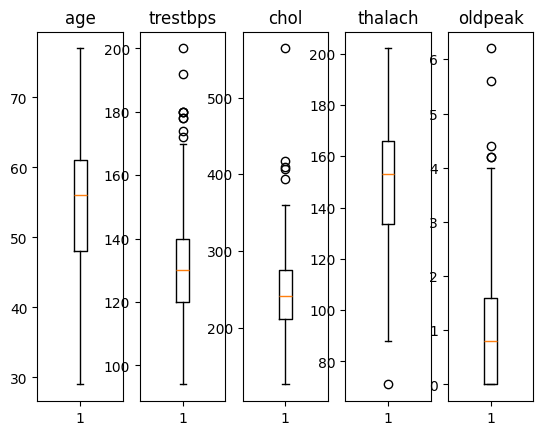

In [80]:
#결측값 출력
print(df.isnull().sum().loc[lambda x: x > 0])

# 연속형 특성에 대해 boxplot
cols = ['age','trestbps','chol','thalach','oldpeak']
fig, subplot = plt.subplots(1, 5)
for idx, col in enumerate(cols):
    subplot[idx].boxplot(df[col])
    subplot[idx].set_title(col)
plt.show()


In [62]:
def iqr_outliers(df, col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    return outliers
for col in cols:
    print(col, len(iqr_outliers(df, col)))


age 0
trestbps 9
chol 5
thalach 1
oldpeak 5


In [68]:
def z_score(df, col):
    z_scores = stats.zscore(df[col])
    threshold = 3
    outliers = df[abs(z_scores) > threshold]
    return outliers
for col in cols:
    print(col, len(z_score(df, col)))

age 0
trestbps 2
chol 4
thalach 1
oldpeak 2


##### IQR 이상치
- age 0개
- trestbps 9개
- chol 5개
- thalach 1개
- oldpeak 5개
##### z-score 이상치
- age 0개
- trestbps 2개
- chol 4개
- thalach 1개
- oldpeak 2개

##### 결측값(컬럼별로 삭제 vs. 평균/중앙값/KNN 대치를 정당화), 이상치, 빈 컬럼, 중복을 처리하는 전처리 파이프라인 구성. 일회성 셀이 아니라 새 데이터에 그대로 재적용 가능한 함수 또는 sklearn.pipeline.Pipeline 형태여야 합니다.

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

# 결측값 처리
def impute_values(df, target_cols=['ca', 'thal']):
    df_impute = df.copy()
    imputer = SimpleImputer(strategy='most_frequent')
    df_impute[target_cols] = imputer.fit_transform(df[target_cols])

    return df_impute
# 이상치 처리
def remove_outlier(df):
    for col in df.columns:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        df[col] = np.clip(df[col], lower_bound, upper_bound)
    return df
# 빈 컬럼 제거
def remove_empty_columns(df, threshold=0.5):
    null_percent = df.isnull().mean()
    cols_to_drop = null_percent[null_percent >= threshold].index.tolist()
    return df.drop(columns=cols_to_drop)
    
# 중복 제거
def remove_duplicate_row(df):
    return df.drop_duplicates().reset_index(drop=True)

def preprocessing_data(df):
    df = remove_empty_columns(df)
    df = remove_outlier(df)
    df = impute_values(df)
    df = remove_duplicate_row(df)
    return df

preprocessing_df = preprocessing_data(df)
print(preprocessing_df)
print(preprocessing_df.shape)

      age  sex   cp  trestbps   chol  ...  oldpeak  slope   ca  thal  target
0    63.0  1.0  1.5     145.0  233.0  ...      2.3    3.0  0.0   6.0       0
1    67.0  1.0  4.0     160.0  286.0  ...      1.5    2.0  2.5   3.0       1
2    67.0  1.0  4.0     120.0  229.0  ...      2.6    2.0  2.0   7.0       1
3    37.0  1.0  3.0     130.0  250.0  ...      3.5    3.0  0.0   3.0       0
4    41.0  0.0  2.0     130.0  204.0  ...      1.4    1.0  0.0   3.0       0
..    ...  ...  ...       ...    ...  ...      ...    ...  ...   ...     ...
298  45.0  1.0  1.5     110.0  264.0  ...      1.2    2.0  0.0   7.0       1
299  68.0  1.0  4.0     144.0  193.0  ...      3.4    2.0  2.0   7.0       1
300  57.0  1.0  4.0     130.0  131.0  ...      1.2    2.0  1.0   7.0       1
301  57.0  0.0  2.0     130.0  236.0  ...      0.0    2.0  1.0   3.0       1
302  38.0  1.0  3.0     138.0  175.0  ...      0.0    1.0  0.0   3.0       0

[303 rows x 14 columns]
(303, 14)


# EDA가 무엇을 알려 주었는가.
- processed.cleveland.data 데이터세트는 총 303개의 행과 14개의 열로 이루어져있다.
- 데이터세트 내의 정상환자의 비율은 54%이고, 심장병 진단 환자비율 46%이다.
- 결측치는 'ca'와 'thal'열에 각각 4, 2개 존재한다.
- 'age','trestbps','chol','thalach','oldpeak'열의 IQR 이상치는 각각 0, 9, 5, 1, 5개이다.
- 'age','trestbps','chol','thalach','oldpeak'열의 z-score 이상치는 각각 0, 2, 4, 1, 2개이다.
# 전처리에서 무엇을 어떻게 바꾸었는가?
1. 결측치 처리
- 삭제/평균/중앙값/KNN 대치 대신 최빈값을 선택하였다.
- ca 값은 막힌 관상동맥의 개수를, thal은 스트레스 테스트의 결과를 나타내는 번호로 각 번호가 의미를 가지고 있는 범주형 데이터이다. 따라서 해당 데이터들은 평균이나 중앙값을 사용하면 안된다.
- KNN 대치는 거리를 거리를 기반으로 작동하여 각 열들의 단위가 다를시 정상동작하지 않으니 StandardScaler를 사용하여야 하나 ca와 thal은 범주형 데이터이므로 적용이 힘듬
- 따라서 최빈값으로 
2. 이상치 처리
- IQR 이상치들을 IQR 범위내로 제한하였다.
3. 빈 컬럼제거
- 결측치 비율이 50% 이상인 열은 제거한다.
4. 중복 제거
- 모든 열이 같은 값을 가지고 있는 행은 제거하였다.
> - 최종적으로 빈 컬럼 제거, 이상치 처리, 결측치 처리, 중복 제거 순으로 진행된다.
